# Analisis Awal Penjualan — April s/d September 2020

Sumber data: `Data Penjualan April - Sep 2020.xlsx` (Sheet1 / Table1, 6.779 baris transaksi).

**Skema kolom**

| Kolom | Arti | Tipe |
|---|---|---|
| `TGL` | Tanggal transaksi | tanggal (serial Excel) |
| `KODEBARA` | Kode barang | teks |
| `NAMABARA` | Nama barang | teks |
| `QTY` | Kuantitas | numerik |
| `SATUAN` | Satuan jual (DUS, PACK, dsb.) | teks |
| `HARGA` | Harga per satuan | numerik (Rp) |
| `JUMLAH` | Nilai baris = QTY x HARGA | numerik (Rp) |
| `NAMA` | Nama pelanggan / outlet | teks |

**Isi notebook**
1. Muat data & profil struktur
2. Pemeriksaan kualitas data
3. Pembersihan & kolom turunan
4. KPI ringkas
5. Grafik: tren waktu, produk, pelanggan, brand, satuan, harga
6. Temuan awal

## 1. Muat data & profil struktur

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda v: f'{v:,.2f}')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

FILE = 'Data Penjualan April - Sep 2020.xlsx'

def baca_xlsx_stdlib(path, sheet='xl/worksheets/sheet1.xml'):
    """Cadangan bila openpyxl belum terpasang: baca xlsx (zip+xml) ke DataFrame."""
    import zipfile
    from xml.etree import ElementTree as ET

    ns = '{http://schemas.openxmlformats.org/spreadsheetml/2006/main}'
    z = zipfile.ZipFile(path)
    shared = [''.join(t.text or '' for t in si.iter(ns + 't'))
              for si in ET.fromstring(z.read('xl/sharedStrings.xml'))]

    def kolom(ref):
        huruf = ''.join(c for c in ref if c.isalpha())
        n = 0
        for c in huruf:
            n = n * 26 + (ord(c) - 64)
        return n - 1

    baris = []
    for row in ET.fromstring(z.read(sheet)).find(ns + 'sheetData').findall(ns + 'row'):
        sel = {}
        for c in row.findall(ns + 'c'):
            v = c.find(ns + 'v')
            if v is None or v.text is None:
                continue
            sel[kolom(c.get('r'))] = shared[int(v.text)] if c.get('t') == 's' else float(v.text)
        baris.append(sel)

    lebar = max(max(r) for r in baris if r) + 1
    tabel = [[r.get(i) for i in range(lebar)] for r in baris]
    return pd.DataFrame(tabel[1:], columns=tabel[0])


try:
    df = pd.read_excel(FILE, sheet_name='Sheet1')
    print('Dibaca via pd.read_excel (openpyxl).')
except ImportError:
    df = baca_xlsx_stdlib(FILE)
    print('openpyxl tidak tersedia -> memakai pembaca cadangan (zip+xml).')
    print('Agar lebih ringkas ke depan: pip install openpyxl')

print('Dimensi:', df.shape)
df.head()

openpyxl tidak tersedia -> memakai pembaca cadangan (zip+xml).
Agar lebih ringkas ke depan: pip install openpyxl
Dimensi: (6779, 8)


,TGL,KODEBARA,NAMABARA,QTY,SATUAN,HARGA,JUMLAH,NAMA
0,"43,922.00",JOF-022,JOFRANS NUGGET AYAM REG. 225 GR X 24 PAK,1.00,DUS,"240,000.00","240,000.00",F - (MITRAKU) TOKO SALMAINI HABABAHAN
1,"43,922.00",JOF-002,JOFRANS NUGGET AYAM REG. 500 GR X 12 PAK,1.00,DUS,"216,000.00","216,000.00",F - (MITRAKU) TOKO SALMAINI HABABAHAN
2,"43,922.00",OKEY-003,OKEY STICK 500 GR X 10 PACK,1.00,DUS,"190,000.00","190,000.00",F - (MITRAKU) TOKO SALMAINI HABABAHAN
3,"43,922.00",OKEY-001,OKEY SOSIS 500 GR X 20 PACK,1.00,DUS,"380,000.00","380,000.00",F - (MITRAKU) TOKO SALMAINI HABABAHAN
4,"43,922.00",BLF-001,BELFOODS SOSIS AYAM 500 GR X 12 PACK,1.00,DUS,"204,000.00","204,000.00",F - (MITRAKU) TOKO SALMAINI HABABAHAN


In [2]:
# Profil struktur: tipe, nilai kosong, kardinalitas
profil = pd.DataFrame({
    'tipe': df.dtypes.astype(str),
    'kosong': df.isna().sum(),
    'kosong_%': (df.isna().mean() * 100).round(2),
    'nilai_unik': df.nunique(),
    'contoh': [df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns],
})
profil

,tipe,kosong,kosong_%,nilai_unik,contoh
TGL,float64,1,0.01,143,"43,922.00"
KODEBARA,str,1,0.01,268,JOF-022
NAMABARA,str,1,0.01,297,JOFRANS NUGGET AYAM REG. 225 GR X 24 PAK
QTY,float64,1,0.01,76,1.00
SATUAN,str,1,0.01,9,DUS
HARGA,float64,1,0.01,387,"240,000.00"
JUMLAH,float64,1,0.01,1076,"240,000.00"
NAMA,str,1,0.01,229,F - (MITRAKU) TOKO SALMAINI HABABAHAN


## 2. Pembersihan & kolom turunan

- `TGL` disimpan sebagai *serial* Excel (mis. `43922`) bila dibaca lewat jalur cadangan → dikonversi dengan origin `1899-12-30`.
- `NAMA` memakai pola prefiks kanal, mis. `F - (MITRAKU) TOKO SALMAINI` → dipisah menjadi `KANAL`, `GRUP`, dan `PELANGGAN`.
- Brand diambil dari kata pertama `NAMABARA` (JOFRANS, OKEY, BELFOODS, ...).

In [3]:
d = df.copy()
d.columns = [c.strip().upper() for c in d.columns]

# --- Tanggal ---
if not pd.api.types.is_datetime64_any_dtype(d['TGL']):
    d['TGL'] = pd.to_datetime(d['TGL'].astype(float), unit='D', origin='1899-12-30')

# Nama bulan dalam bahasa Indonesia, disimpan sebagai kategori TERURUT supaya
# groupby dan pengurutan tetap kronologis (Mei sebelum September), bukan alfabetis.
NAMA_BULAN = ['Januari', 'Februari', 'Maret', 'April', 'Mei', 'Juni',
              'Juli', 'Agustus', 'September', 'Oktober', 'November', 'Desember']


def label_bulan(tgl):
    '''Ubah kolom tanggal menjadi label bulan bernama, mis. "April 2020".'''
    periode = tgl.dt.to_period('M')
    sebut = lambda p: pd.NA if pd.isna(p) else f'{NAMA_BULAN[p.month - 1]} {p.year}'
    urut = [sebut(p) for p in sorted(periode.dropna().unique())]
    return pd.Categorical(periode.map(sebut), categories=urut, ordered=True)


d['BULAN'] = label_bulan(d['TGL'])
d['HARI'] = d['TGL'].dt.day_name()

# --- Numerik ---
for c in ['QTY', 'HARGA', 'JUMLAH']:
    d[c] = pd.to_numeric(d[c], errors='coerce')

# --- Teks ---
for c in ['KODEBARA', 'NAMABARA', 'SATUAN', 'NAMA']:
    d[c] = d[c].astype('string').str.strip()

# --- Pecah NAMA: "F - (MITRAKU) TOKO SALMAINI HABABAHAN" ---
pola = r'^\s*(?:(?P<KANAL>[A-Z0-9]{1,3})\s*-\s*)?(?:\((?P<GRUP>[^)]*)\)\s*)?(?P<PELANGGAN>.*)$'
pecah = d['NAMA'].str.extract(pola)
d['KANAL'] = pecah['KANAL'].fillna('(tanpa kode)')
d['GRUP'] = pecah['GRUP'].fillna('(tanpa grup)')
d['PELANGGAN'] = pecah['PELANGGAN'].str.strip().replace('', pd.NA).fillna(d['NAMA'])

# --- Nama barang kanonik ---
# 25 kode barang punya lebih dari satu ejaan nama (lihat bagian 3). Tanpa
# penyeragaman ini satu SKU terhitung sebagai beberapa SKU dan peringkat produk
# maupun kurva Pareto ikut melenceng.
kanonik = (d.dropna(subset=['KODEBARA'])
             .groupby('KODEBARA')['NAMABARA']
             .agg(lambda s: s.value_counts().idxmax()))
d['NAMA_KANONIK'] = d['KODEBARA'].map(kanonik).fillna(d['NAMABARA'])

# --- Brand dari nama barang ---
d['BRAND'] = d['NAMA_KANONIK'].str.split().str[0].str.upper()

# --- Konsistensi nilai baris ---
d['JUMLAH_HITUNG'] = d['QTY'] * d['HARGA']
d['SELISIH'] = (d['JUMLAH'] - d['JUMLAH_HITUNG']).round(2)

print('Rentang tanggal :', d['TGL'].min().date(), '->', d['TGL'].max().date())
print('Jumlah baris    :', len(d))
print('SKU unik (kode) :', d['KODEBARA'].nunique(), '| variasi nama mentah:', d['NAMABARA'].nunique())
d[['TGL', 'KODEBARA', 'NAMA_KANONIK', 'QTY', 'SATUAN', 'HARGA', 'JUMLAH', 'KANAL', 'GRUP', 'PELANGGAN', 'BRAND']].head()

Rentang tanggal : 2020-04-01 -> 2020-09-30
Jumlah baris    : 6779
SKU unik (kode) : 268 | variasi nama mentah: 297


,TGL,KODEBARA,NAMA_KANONIK,QTY,SATUAN,HARGA,JUMLAH,KANAL,GRUP,PELANGGAN,BRAND
0,2020-04-01,JOF-022,JOFRANS NUGGET AYAM REG. 225 GR X 24 PAK,1.00,DUS,"240,000.00","240,000.00",F,MITRAKU,TOKO SALMAINI HABABAHAN,JOFRANS
1,2020-04-01,JOF-002,JOFRANS NUGGET AYAM REG. 500 GR X 12 PAK,1.00,DUS,"216,000.00","216,000.00",F,MITRAKU,TOKO SALMAINI HABABAHAN,JOFRANS
2,2020-04-01,OKEY-003,OKEY STICK 500 GR X 10 PACK,1.00,DUS,"190,000.00","190,000.00",F,MITRAKU,TOKO SALMAINI HABABAHAN,OKEY
3,2020-04-01,OKEY-001,OKEY SOSIS 500 GR X 20 PACK,1.00,DUS,"380,000.00","380,000.00",F,MITRAKU,TOKO SALMAINI HABABAHAN,OKEY
4,2020-04-01,BLF-001,BELFOODS SOSIS AYAM 500 GR X 12 PACK,1.00,DUS,"204,000.00","204,000.00",F,MITRAKU,TOKO SALMAINI HABABAHAN,BELFOODS


## 3. Pemeriksaan kualitas data

Dilakukan **sebelum** analisis agar angka KPI tidak menyesatkan.

In [4]:
cek = {
    'baris duplikat penuh': int(d.duplicated().sum()),
    'QTY <= 0': int((d['QTY'] <= 0).sum()),
    'HARGA <= 0': int((d['HARGA'] <= 0).sum()),
    'JUMLAH <= 0 (retur?)': int((d['JUMLAH'] <= 0).sum()),
    'JUMLAH != QTY x HARGA': int((d['SELISIH'].abs() > 0.5).sum()),
    'TGL kosong': int(d['TGL'].isna().sum()),
    'NAMA kosong': int(d['NAMA'].isna().sum()),
    'KODEBARA kosong': int(d['KODEBARA'].isna().sum()),
}
ringkas = pd.Series(cek, name='jumlah_baris').to_frame()
ringkas['persen'] = (ringkas['jumlah_baris'] / len(d) * 100).round(2)
display(ringkas)

# Satu kode barang seharusnya satu nama barang — cek penamaan tidak konsisten
nama_ganda = d.groupby('KODEBARA')['NAMABARA'].nunique()
nama_ganda = nama_ganda[nama_ganda > 1]
print(f'\nKode barang dengan >1 variasi nama: {len(nama_ganda)}')
if len(nama_ganda):
    display(d[d['KODEBARA'].isin(nama_ganda.index)]
            .groupby(['KODEBARA', 'NAMABARA']).size().rename('baris').head(20))

,jumlah_baris,persen
baris duplikat penuh,73,1.08
QTY <= 0,0,0.00
HARGA <= 0,58,0.86
JUMLAH <= 0 (retur?),58,0.86
JUMLAH != QTY x HARGA,77,1.14
TGL kosong,1,0.01
NAMA kosong,1,0.01
KODEBARA kosong,1,0.01



Kode barang dengan >1 variasi nama: 25


KODEBARA    NAMABARA                                
ARTHUR-001  ARTHUR SHOESTRING 2.5 KG X 4 PACK           13
            LUTOSA SHOESTRING 2.5 KG X 4 PACK            5
            MR ARTHUR SHOESTRING 2.5 KG X 4 PACK         5
BAKSO-001   BAKSO ANEKA WARNA 250 GR                     9
            ILM BAKSO ANEKA WARNA 250 GR                19
            ILM NBAKSO ANEKA WARNA 250 GR                1
BAKSO-002   BAKSO BINTANG 250 GR                         9
            ILM BAKSO BINTANG 250 GR                    22
BAKSO-003   BAKSO OLAHAN IKAN TAHU 200 GR                9
            ILM BAKSO IKAN OLAHAN BENTUK TAHU 200 GR    20
            ILM BAKSO OLAHAN IKAN TAHU 200 GR            7
BESTO-002   BESTO BRATW SAPI BAKAR ORI 9 CM 500GRX20     1
            BESTO BRATWURST BAKAR ORI 500 GRX20 PAK      3
BLF-016     BELFOODS AYAM GORENG RENYAH 500GRX12         1
            BELFOODS FAV.AYAM GORENG RENYAH 500GRX12     4
CAV-001     CAVENDISH SHOESTRING 2.94 KG X 6 PACK        5
   

In [5]:
# Contoh baris bermasalah (bila ada) untuk ditelaah manual
masalah = d[(d['SELISIH'].abs() > 0.5) | (d['QTY'] <= 0) | (d['JUMLAH'] <= 0)]
print('Total baris bermasalah:', len(masalah))
masalah[['TGL', 'KODEBARA', 'NAMABARA', 'QTY', 'HARGA', 'JUMLAH', 'JUMLAH_HITUNG', 'SELISIH', 'NAMA']].head(15)

Total baris bermasalah: 135


,TGL,KODEBARA,NAMABARA,QTY,HARGA,JUMLAH,JUMLAH_HITUNG,SELISIH,NAMA
39,2020-04-02,MIT-010,MITRAKU FISH ROLL 250 GR X 25 PACK,13.00,"13,000.00","155,480.00","169,000.00","-13,520.00",C - (MITRAKU) RAISYA FROZEN
40,2020-04-02,MIT-009,MITRAKU FISH ROLL 500 GR X 20 PACK,6.00,"23,400.00","129,168.00","140,400.00","-11,232.00",C - (MITRAKU) RAISYA FROZEN
41,2020-04-02,MIT-011,MITRAKU FISH ROLL 1000 GR X 10 PACK,4.00,"46,000.00","169,280.00","184,000.00","-14,720.00",C - (MITRAKU) RAISYA FROZEN
48,2020-04-02,MIT-016,MITRAKU FISH CAKE SINGAPORE 1000 GR X 10,6.00,"52,000.00","287,040.00","312,000.00","-24,960.00",C - (MITRAKU) RAISYA FROZEN
55,2020-04-02,MIT-004,MITRAKU BAKSO PILUS IKAN 400GR X 23 PACK,10.00,"14,900.00","141,550.00","149,000.00","-7,450.00",E - MAJU JAYA
56,2020-04-02,MIT-009,MITRAKU FISH ROLL 500 GR X 20 PACK,10.00,"23,400.00","222,300.00","234,000.00","-11,700.00",E - MAJU JAYA
57,2020-04-02,MIT-010,MITRAKU FISH ROLL 250 GR X 25 PACK,5.00,"13,000.00","61,750.00","65,000.00","-3,250.00",E - MAJU JAYA
58,2020-04-02,MIT-010,MITRAKU FISH ROLL 250 GR X 25 PACK,1.00,0.00,0.00,0.00,0.00,E - MAJU JAYA
76,2020-04-02,MIT-010,MITRAKU FISH ROLL 250 GR X 25 PACK,1.00,0.00,0.00,0.00,0.00,E - RETRO
393,2020-04-11,MIT-016,MITRAKU FISH CAKE SINGAPORE 1000 GR X 10,5.00,"520,000.00","2,340,000.00","2,600,000.00","-260,000.00",F - PAK SUPRI


## 4. KPI ringkas

In [6]:
hari_aktif = d['TGL'].nunique()
kpi = pd.Series({
    'Total omzet (Rp)': d['JUMLAH'].sum(),
    'Total baris transaksi': len(d),
    'Hari dengan penjualan': hari_aktif,
    'Rata-rata omzet / hari aktif (Rp)': d['JUMLAH'].sum() / hari_aktif,
    'Rata-rata nilai per baris (Rp)': d['JUMLAH'].mean(),
    'Median nilai per baris (Rp)': d['JUMLAH'].median(),
    'Jumlah pelanggan unik': d['PELANGGAN'].nunique(),
    'Jumlah SKU unik': d['KODEBARA'].nunique(),
    'Jumlah brand unik': d['BRAND'].nunique(),
    'Total kuantitas terjual': d['QTY'].sum(),
})
kpi.to_frame('nilai')

,nilai
Total omzet (Rp),"4,530,330,620.00"
Total baris transaksi,"6,779.00"
Hari dengan penjualan,143.00
Rata-rata omzet / hari aktif (Rp),"31,680,633.71"
Rata-rata nilai per baris (Rp),"668,387.52"
Median nilai per baris (Rp),"240,000.00"
Jumlah pelanggan unik,183.00
Jumlah SKU unik,268.00
Jumlah brand unik,74.00
Total kuantitas terjual,"46,704.00"


## 5. Grafik

### 5.1 Tren waktu

,omzet,baris,qty,pelanggan,pertumbuhan_%
BULAN,,,,,
April 2020,"609,614,133.00",1029,"6,388.00",94,NaN
Mei 2020,"706,718,094.00",985,"6,994.00",88,15.90
Juni 2020,"772,238,225.00",1200,"7,748.00",100,9.30
Juli 2020,"811,359,804.00",1325,"9,978.00",96,5.10
Agustus 2020,"883,314,940.00",1068,"8,293.00",112,8.90
September 2020,"747,085,424.00",1171,"7,303.00",95,-15.40


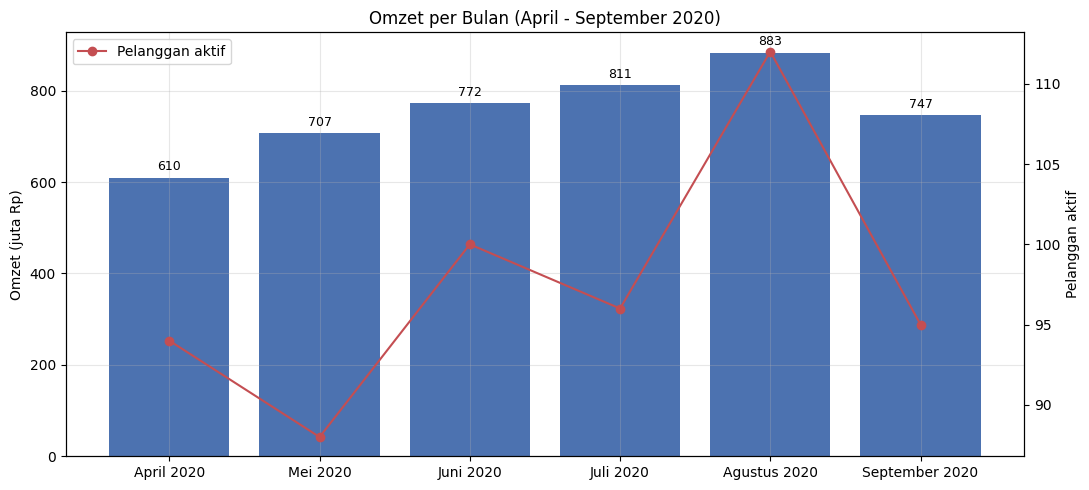

In [7]:
bulanan = d.groupby('BULAN').agg(
    omzet=('JUMLAH', 'sum'),
    baris=('JUMLAH', 'size'),
    qty=('QTY', 'sum'),
    pelanggan=('PELANGGAN', 'nunique'),
)
bulanan['pertumbuhan_%'] = (bulanan['omzet'].pct_change() * 100).round(1)
display(bulanan)

fig, ax = plt.subplots(figsize=(11, 5))
label = list(bulanan.index.astype(str))
bar = ax.bar(label, bulanan['omzet'] / 1e6, color='#4C72B0')
ax.set_title('Omzet per Bulan (April - September 2020)')
ax.set_ylabel('Omzet (juta Rp)')
ax.bar_label(bar, fmt='%.0f', padding=3, fontsize=9)

ax2 = ax.twinx()
ax2.plot(label, bulanan['pelanggan'], color='#C44E52', marker='o', label='Pelanggan aktif')
ax2.set_ylabel('Pelanggan aktif')
ax2.grid(False)
ax2.legend(loc='upper left')
plt.tight_layout()
plt.show()

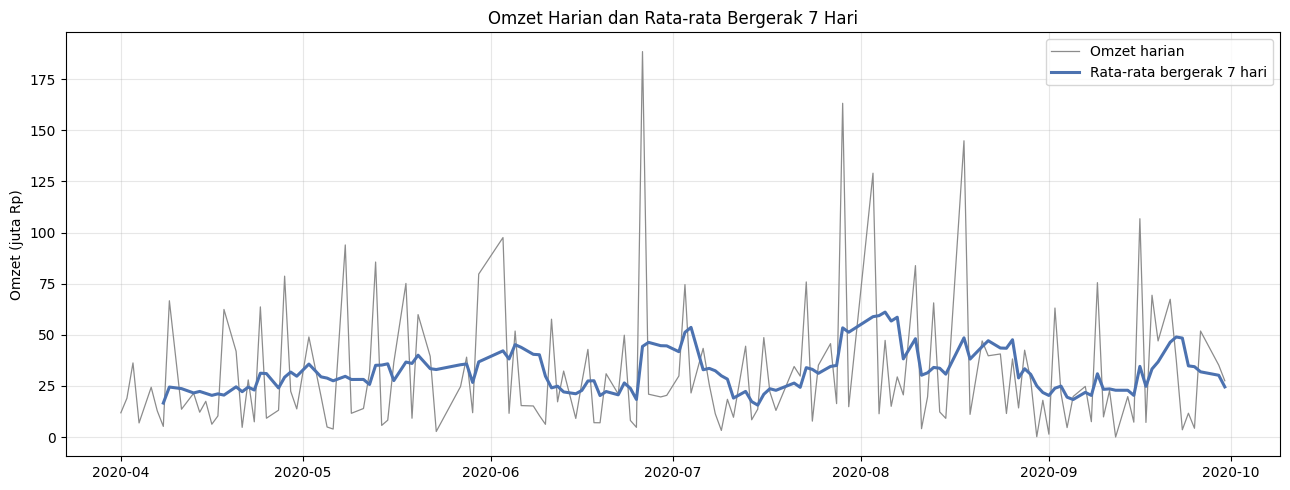

5 hari omzet tertinggi:


TGL
2020-06-26   188.49
2020-07-29   163.21
2020-08-18   144.88
2020-08-03   129.03
2020-09-16   106.77
Name: juta Rp, dtype: float64

In [8]:
harian = d.groupby('TGL')['JUMLAH'].sum().sort_index()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(harian.index, harian.values / 1e6, lw=0.9, color='#8C8C8C', label='Omzet harian')
ax.plot(harian.index, harian.rolling(7).mean() / 1e6, lw=2.2, color='#4C72B0', label='Rata-rata bergerak 7 hari')
ax.set_title('Omzet Harian dan Rata-rata Bergerak 7 Hari')
ax.set_ylabel('Omzet (juta Rp)')
ax.legend()
plt.tight_layout()
plt.show()

print('5 hari omzet tertinggi:')
display((harian.sort_values(ascending=False).head() / 1e6).round(2).rename('juta Rp'))

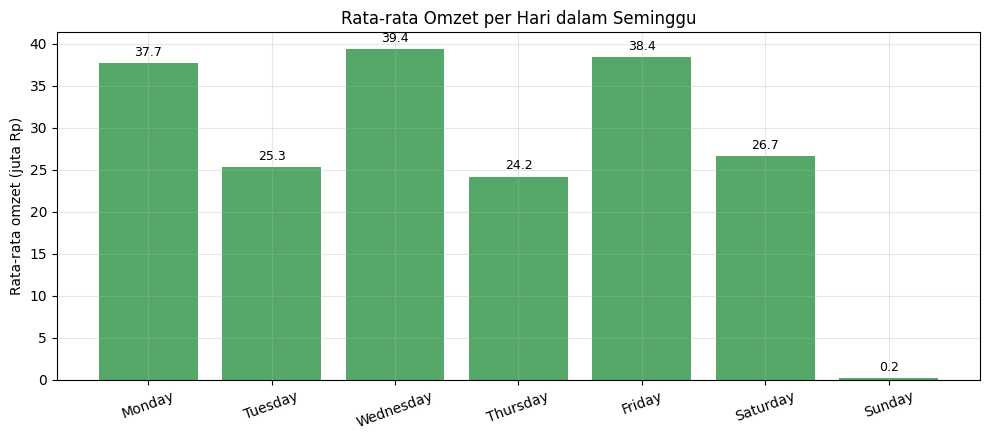

In [9]:
urut = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
per_hari = d.groupby('HARI')['JUMLAH'].sum().reindex(urut).fillna(0)
# dibagi jumlah kemunculan hari agar adil
bobot = d.drop_duplicates('TGL')['HARI'].value_counts().reindex(urut).fillna(0)
rata_hari = (per_hari / bobot.replace(0, np.nan)).fillna(0)

fig, ax = plt.subplots(figsize=(10, 4.5))
b = ax.bar(urut, rata_hari / 1e6, color='#55A868')
ax.bar_label(b, fmt='%.1f', padding=3, fontsize=9)
ax.set_title('Rata-rata Omzet per Hari dalam Seminggu')
ax.set_ylabel('Rata-rata omzet (juta Rp)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 5.2 Produk

,,omzet,qty,transaksi,kontribusi_%
KODEBARA,NAMA_KANONIK,,,,
MIN-001,MINAKU OTAK OTAK 500 GR X 20 PACK,"967,688,500.00","3,830.00",378,21.36
OKEY-001,OKEY SOSIS 500 GR X 20 PACK,"336,460,000.00","1,624.00",288,7.43
LUTOSA-002,LUTOSA SHOESTRING 2.5 KG X 4 PACK,"190,984,250.00","1,052.00",167,4.22
JOF-023,JOFRANS NUGGET AYAM HATI 500 GR X 12 PAK,"160,543,500.00","1,274.00",244,3.54
OKEY-003,OKEY STICK 500 GR X 10 PACK,"156,563,000.00","1,147.00",278,3.46
EURIAL-001,EURIAL MOZZARELLA CHEESE 4 X 2.5 KG,"132,080,000.00",150.00,32,2.92
MI-001,MIAMI 8 LTR NEAPOLITAN CHOCO CHIPS,"128,862,000.00","1,032.00",136,2.84
INDO-002,INDOESKRIM 8 LTR VANILLA,"125,015,000.00",875.00,46,2.76
OKEY-002,OKEY SOSIS 1000 GR X 10 PACK,"113,187,500.00",462.00,100,2.50


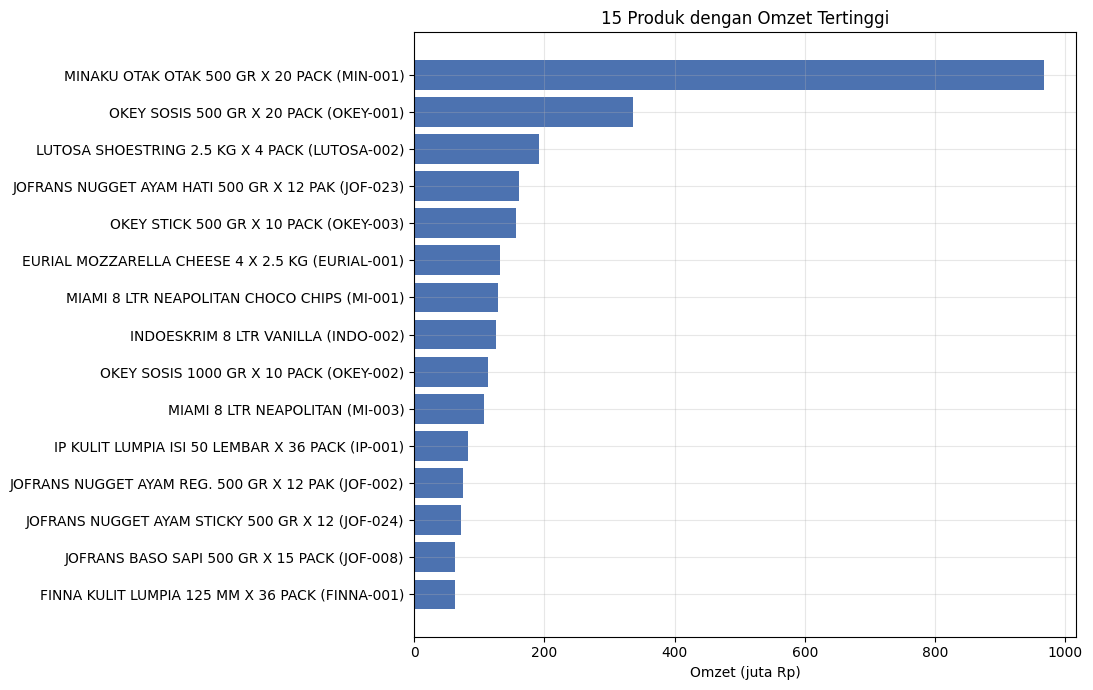

In [10]:
produk = (d.groupby(['KODEBARA', 'NAMA_KANONIK'])
            .agg(omzet=('JUMLAH', 'sum'), qty=('QTY', 'sum'), transaksi=('JUMLAH', 'size'))
            .sort_values('omzet', ascending=False))
produk['kontribusi_%'] = (produk['omzet'] / produk['omzet'].sum() * 100).round(2)
display(produk.head(20))

top = produk.head(15).reset_index()
nama_pendek = top['NAMA_KANONIK'].str.slice(0, 42) + ' (' + top['KODEBARA'] + ')'

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(nama_pendek[::-1], top['omzet'][::-1] / 1e6, color='#4C72B0')
ax.set_title('15 Produk dengan Omzet Tertinggi')
ax.set_xlabel('Omzet (juta Rp)')
plt.tight_layout()
plt.show()

38 dari 268 SKU (14.2%) menyumbang 80% omzet.


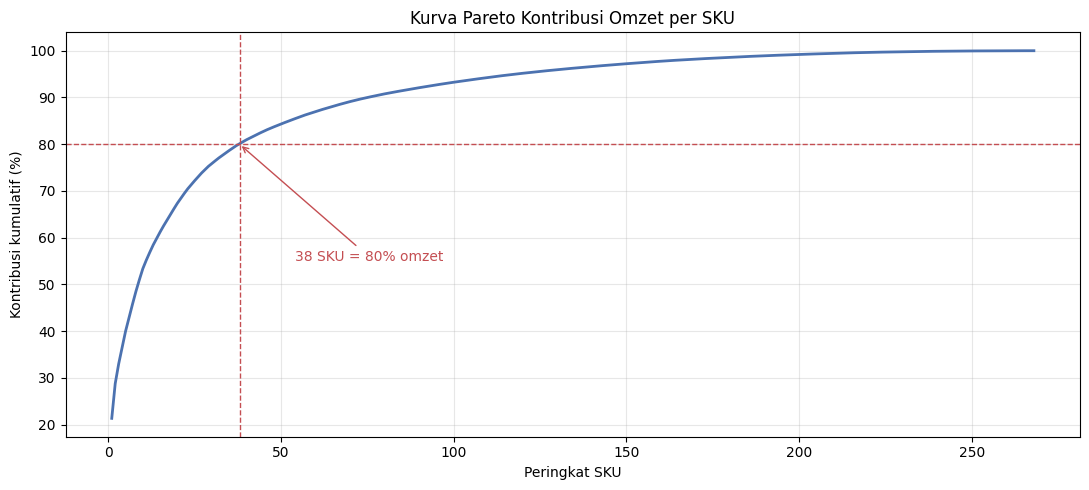

In [11]:
# Pareto: berapa sedikit SKU yang menyumbang 80% omzet?
kum = produk['omzet'].cumsum() / produk['omzet'].sum() * 100
n80 = int((kum <= 80).sum() + 1)
print(f'{n80} dari {len(produk)} SKU ({n80/len(produk)*100:.1f}%) menyumbang 80% omzet.')

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(range(1, len(kum) + 1), kum.values, color='#4C72B0', lw=2)
ax.axhline(80, color='#C44E52', ls='--', lw=1)
ax.axvline(n80, color='#C44E52', ls='--', lw=1)
ax.annotate(f'{n80} SKU = 80% omzet', xy=(n80, 80), xytext=(n80 + len(kum) * 0.06, 55),
            arrowprops=dict(arrowstyle='->', color='#C44E52'), color='#C44E52')
ax.set_title('Kurva Pareto Kontribusi Omzet per SKU')
ax.set_xlabel('Peringkat SKU')
ax.set_ylabel('Kontribusi kumulatif (%)')
plt.tight_layout()
plt.show()

### 5.3 Pelanggan & kanal

,omzet,transaksi,hari_beli,sku,kontribusi_%
PELANGGAN,,,,,
TOKO CITA RASA BARU,"547,771,782.00",528,50,160,12.09
ADEK FROZEN,"420,727,170.00",286,11,90,9.29
ANTON,"311,758,150.00",145,28,62,6.88
HITE,"229,861,080.00",83,13,26,5.07
RUMAH SOSIS,"182,693,450.00",166,27,44,4.03
GRAHA SANDENI,"163,225,800.00",69,15,37,3.60
FIRDON,"154,756,000.00",25,15,9,3.42
PT. DINAMIKA BUAH N.,"139,880,850.00",190,46,31,3.09
PAK SUTARMUJI,"126,400,000.00",2,2,1,2.79


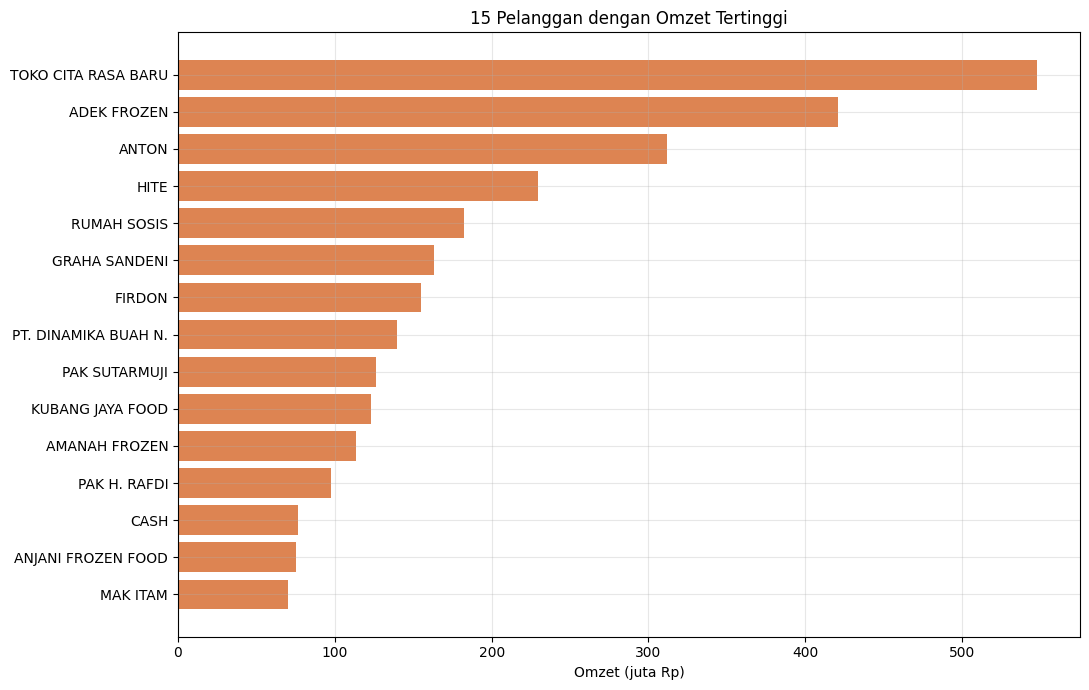

37 dari 183 pelanggan (20.2%) menyumbang 80% omzet.


In [12]:
pelanggan = (d.groupby('PELANGGAN')
               .agg(omzet=('JUMLAH', 'sum'), transaksi=('JUMLAH', 'size'),
                    hari_beli=('TGL', 'nunique'), sku=('KODEBARA', 'nunique'))
               .sort_values('omzet', ascending=False))
pelanggan['kontribusi_%'] = (pelanggan['omzet'] / pelanggan['omzet'].sum() * 100).round(2)
display(pelanggan.head(20))

topc = pelanggan.head(15)
fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(topc.index.str.slice(0, 45)[::-1], topc['omzet'][::-1] / 1e6, color='#DD8452')
ax.set_title('15 Pelanggan dengan Omzet Tertinggi')
ax.set_xlabel('Omzet (juta Rp)')
plt.tight_layout()
plt.show()

kum_c = pelanggan['omzet'].cumsum() / pelanggan['omzet'].sum() * 100
n80c = int((kum_c <= 80).sum() + 1)
print(f'{n80c} dari {len(pelanggan)} pelanggan ({n80c/len(pelanggan)*100:.1f}%) menyumbang 80% omzet.')

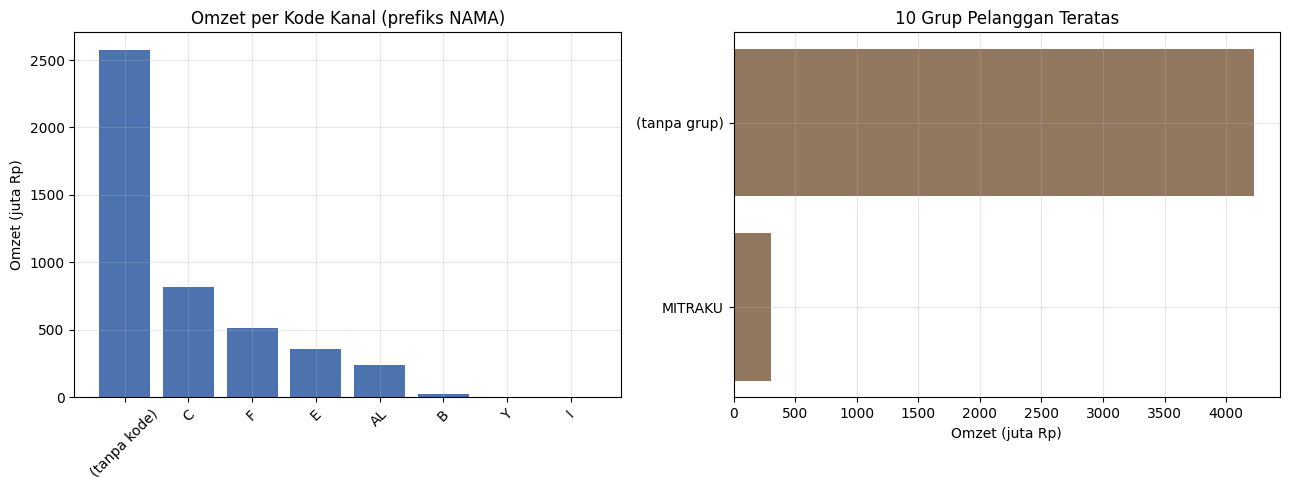

In [13]:
kanal = d.groupby('KANAL')['JUMLAH'].sum().sort_values(ascending=False)
grup = d.groupby('GRUP')['JUMLAH'].sum().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(kanal.index.astype(str), kanal.values / 1e6, color='#4C72B0')
axes[0].set_title('Omzet per Kode Kanal (prefiks NAMA)')
axes[0].set_ylabel('Omzet (juta Rp)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].barh(grup.index.astype(str)[::-1], grup.values[::-1] / 1e6, color='#937860')
axes[1].set_title('10 Grup Pelanggan Teratas')
axes[1].set_xlabel('Omzet (juta Rp)')
plt.tight_layout()
plt.show()

### 5.4 Brand, satuan, dan harga

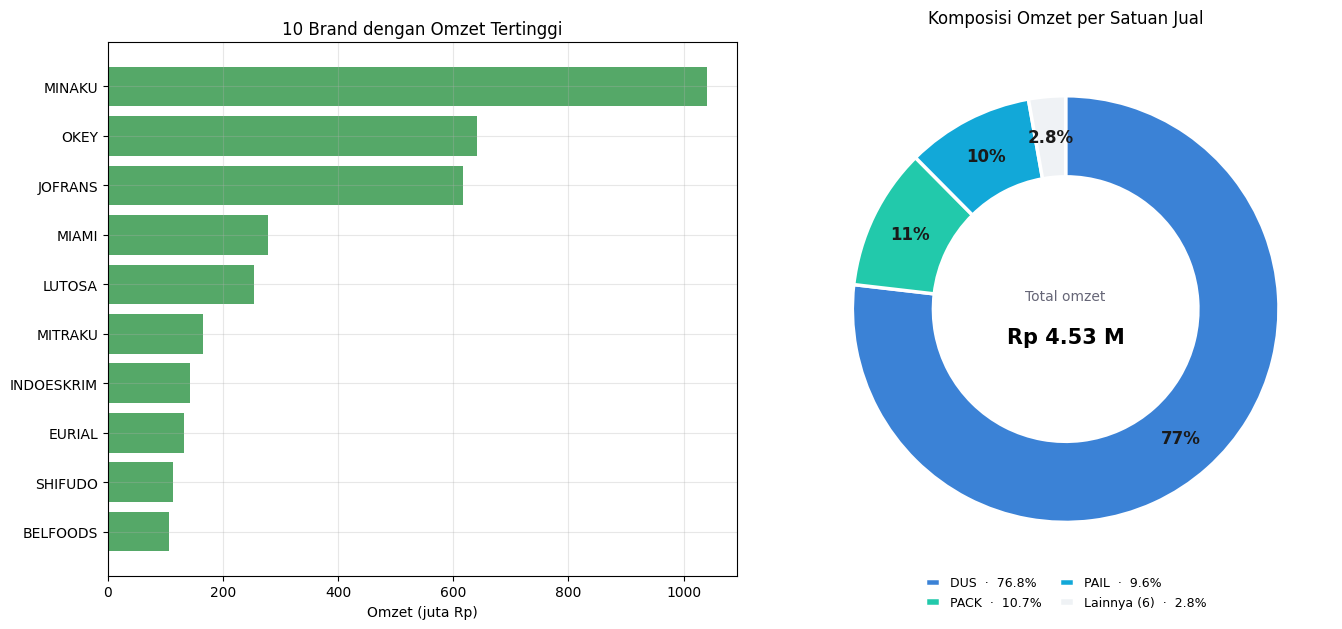

In [14]:
# --- Donut serbaguna, dipakai ulang di seluruh notebook -----------------------
# Dua hal yang membuat donut gagal terbaca sudah ditangani di sini:
# 1) irisan mungil digabung jadi "Lainnya" -- inilah penyebab label saling menimpa;
# 2) persentase ditulis di dalam cincin, bukan di luar dengan garis penunjuk.
PALET_DONUT = ['#3B82D6', '#22C9AB', '#12A8D8', '#EFF2F5', '#DCDFE3', '#9CA6B0', '#6B7784']


def donut(ax, seri, judul, ambang=3.0, palet=None, teks_pusat='Total omzet'):
    """Gambar donut komposisi. `ambang` = batas % di bawahnya irisan digabung."""
    seri = seri.sort_values(ascending=False)
    total = seri.sum()
    kecil = seri / total * 100 < ambang
    if kecil.sum() > 1:
        seri = pd.concat([seri[~kecil],
                          pd.Series({f'Lainnya ({int(kecil.sum())})': seri[kecil].sum()})])
    palet = list(palet or PALET_DONUT)
    warna = [palet[i % len(palet)] for i in range(len(seri))]
    w, _, teks = ax.pie(seri.values, colors=warna, startangle=90, counterclock=False,
                        wedgeprops=dict(width=0.38, edgecolor='white', lw=2.5),
                        autopct=lambda v: f'{v:.0f}%' if v >= 4 else f'{v:.1f}%',
                        pctdistance=0.81,
                        textprops=dict(fontsize=12, fontweight='bold', color='#1A1A1A'))
    # Irisan di bawah 2,2% tetap tanpa label di cincin; angkanya ada di legenda.
    for t, wedge in zip(teks, w):
        if (wedge.theta2 - wedge.theta1) / 360 * 100 < 2.2:
            t.set_text('')
    if teks_pusat:
        ax.text(0, 0.06, teks_pusat, ha='center', va='center', fontsize=10, color='#667')
        ax.text(0, -0.13, f'Rp {total / 1e9:.2f} M', ha='center', va='center',
                fontsize=15, fontweight='bold')
    ax.set_title(judul, fontsize=12, pad=14)
    ax.legend(w, [f'{i}  ·  {v / total * 100:.1f}%' for i, v in seri.items()],
              loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=2, fontsize=9,
              frameon=False, handlelength=1.2, columnspacing=1.4)


brand = d.groupby('BRAND')['JUMLAH'].sum().sort_values(ascending=False)
satuan = d.groupby('SATUAN').agg(omzet=('JUMLAH', 'sum'), baris=('JUMLAH', 'size'))

fig, axes = plt.subplots(1, 2, figsize=(14, 6.4))
b10 = brand.head(10)
axes[0].barh(b10.index.astype(str)[::-1], b10.values[::-1] / 1e6, color='#55A868')
axes[0].set_title('10 Brand dengan Omzet Tertinggi')
axes[0].set_xlabel('Omzet (juta Rp)')

donut(axes[1], satuan['omzet'], 'Komposisi Omzet per Satuan Jual')
plt.tight_layout()
plt.show()


### 5.5 Komposisi omzet dalam donut

Persentase ditulis langsung di cincin. Irisan di bawah ambang digabung menjadi
"Lainnya" -- tanpa itu, 69 brand berekor panjang menghasilkan tumpukan label yang
saling menimpa dan tidak terbaca.


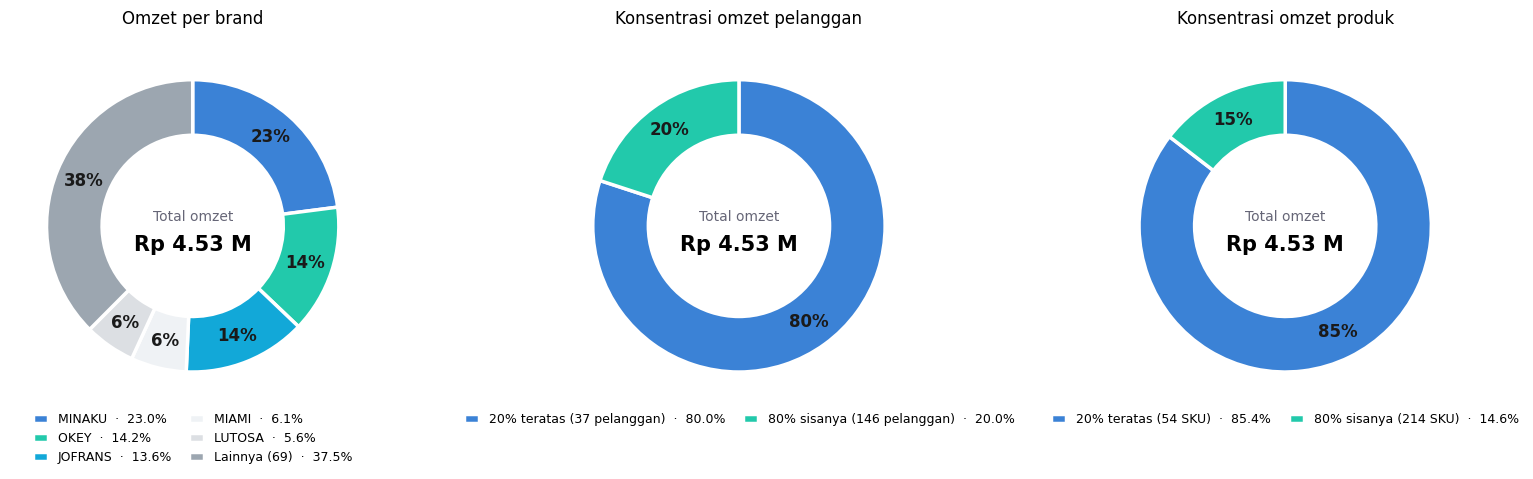

Pareto pelanggan : 37 teratas (20%) -> 80.0% omzet
Pareto produk    : 54 teratas (20%) -> 85.4% omzet


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 6.8))

# (a) Brand -- 69 brand ekor panjang otomatis masuk "Lainnya".
donut(axes[0], d.groupby('BRAND')['JUMLAH'].sum(), 'Omzet per brand', ambang=4.0)

# (b) Pareto pelanggan: benarkah 20% pelanggan menyumbang 80% omzet?
pel = d.groupby('PELANGGAN')['JUMLAH'].sum().sort_values(ascending=False)
n20 = round(len(pel) * 0.2)
donut(axes[1], pd.Series({f'20% teratas ({n20} pelanggan)': pel.head(n20).sum(),
                          f'80% sisanya ({len(pel) - n20} pelanggan)': pel.iloc[n20:].sum()}),
      'Konsentrasi omzet pelanggan', ambang=0)

# (c) Pareto SKU, pertanyaan yang sama untuk sisi produk.
sku = d.groupby('KODEBARA')['JUMLAH'].sum().sort_values(ascending=False)
s20 = round(len(sku) * 0.2)
donut(axes[2], pd.Series({f'20% teratas ({s20} SKU)': sku.head(s20).sum(),
                          f'80% sisanya ({len(sku) - s20} SKU)': sku.iloc[s20:].sum()}),
      'Konsentrasi omzet produk', ambang=0)

plt.tight_layout()
plt.show()

print(f'Pareto pelanggan : {n20} teratas (20%) -> {pel.head(n20).sum() / pel.sum() * 100:.1f}% omzet')
print(f'Pareto produk    : {s20} teratas (20%) -> {sku.head(s20).sum() / sku.sum() * 100:.1f}% omzet')


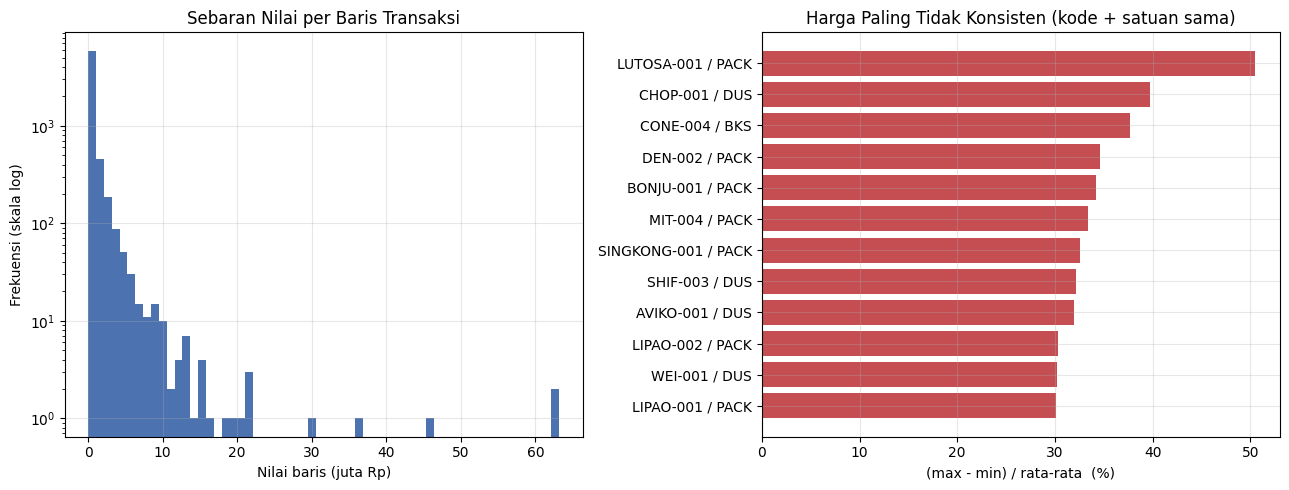

Kombinasi kode+satuan dengan >1 tingkat harga: 288 dari 404 (71.3%)
Sebagian wajar (diskon/tier pelanggan), sebagian lain layak dicek sebagai salah input.


,,min,max,nunique,mean,baris,rentang_pct
KODEBARA,SATUAN,,,,,,
LUTOSA-001,PACK,"15,000.00","28,000.00",7,"25,719.70",66,50.50
CHOP-001,DUS,"163,200.00","240,000.00",7,"193,224.49",49,39.70
CONE-004,BKS,"5,000.00","7,000.00",3,"5,300.00",20,37.70
DEN-002,PACK,"4,000.00","6,000.00",3,"5,777.78",18,34.60
BONJU-001,PACK,"14,000.00","20,000.00",10,"17,523.26",86,34.20
MIT-004,PACK,"11,500.00","16,500.00",5,"14,956.00",25,33.40
SINGKONG-001,PACK,"8,750.00","12,500.00",4,"11,515.62",16,32.60
SHIF-003,DUS,"196,200.00","262,500.00",3,"206,170.91",11,32.20
AVIKO-001,DUS,"200,000.00","270,000.00",6,"219,444.44",9,31.90


In [16]:
# Sebaran nilai baris + konsistensi harga.
# Catatan: harga HARUS dibandingkan per (KODEBARA, SATUAN). Satu kode yang dijual
# dalam DUS dan PACK wajar punya harga berbeda; yang perlu ditelaah adalah harga
# berbeda untuk kode DAN satuan yang sama.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(d['JUMLAH'] / 1e6, bins=60, color='#4C72B0')
axes[0].set_yscale('log')
axes[0].set_title('Sebaran Nilai per Baris Transaksi')
axes[0].set_xlabel('Nilai baris (juta Rp)')
axes[0].set_ylabel('Frekuensi (skala log)')

var_harga = (d[d['HARGA'] > 0]
             .groupby(['KODEBARA', 'SATUAN'])['HARGA']
             .agg(['min', 'max', 'nunique', 'mean', 'size'])
             .rename(columns={'size': 'baris'}))
var_harga['rentang_pct'] = ((var_harga['max'] - var_harga['min']) / var_harga['mean'] * 100).round(1)

# hanya kombinasi yang cukup sering muncul, agar bukan sekadar kasus tunggal
vh = (var_harga[(var_harga['nunique'] > 1) & (var_harga['baris'] >= 5)]
      .sort_values('rentang_pct', ascending=False).head(12))
label_vh = [f'{k} / {s}' for k, s in vh.index]

axes[1].barh(label_vh[::-1], vh['rentang_pct'][::-1], color='#C44E52')
axes[1].set_title('Harga Paling Tidak Konsisten (kode + satuan sama)')
axes[1].set_xlabel('(max - min) / rata-rata  (%)')
plt.tight_layout()
plt.show()

n_var = int((var_harga['nunique'] > 1).sum())
print(f'Kombinasi kode+satuan dengan >1 tingkat harga: {n_var} dari {len(var_harga)} '
      f'({n_var / len(var_harga) * 100:.1f}%)')
print('Sebagian wajar (diskon/tier pelanggan), sebagian lain layak dicek sebagai salah input.')
display(vh)

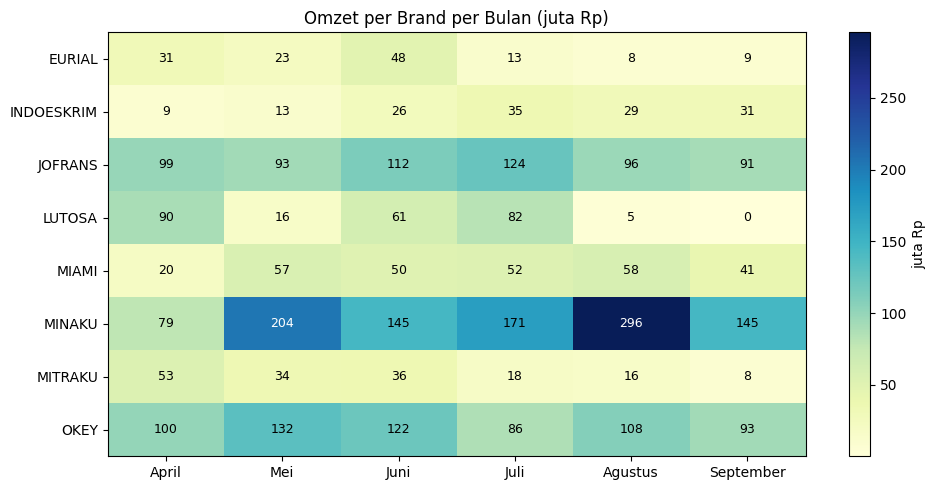

In [17]:
# Heatmap: omzet brand teratas per bulan (melihat pergeseran mix)
brand_top = brand.head(8).index
pivot = (d[d['BRAND'].isin(brand_top)]
         .pivot_table(index='BRAND', columns='BULAN', values='JUMLAH', aggfunc='sum', fill_value=0) / 1e6)
pivot.columns = [str(c).split()[0] for c in pivot.columns]   # 'April 2020' -> 'April'

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(pivot.values, aspect='auto', cmap='YlGnBu')
ax.set_xticks(range(len(pivot.columns)), pivot.columns)
ax.set_yticks(range(len(pivot.index)), pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        ax.text(j, i, f'{v:.0f}', ha='center', va='center',
                color='white' if v > pivot.values.max() * 0.6 else 'black', fontsize=9)
ax.set_title('Omzet per Brand per Bulan (juta Rp)')
ax.grid(False)
fig.colorbar(im, ax=ax, label='juta Rp')
plt.tight_layout()
plt.show()

## 6. Temuan awal

Sel di bawah merangkum angka-angka kunci secara otomatis agar tidak ada nilai yang ditulis manual.

In [18]:
bln_max = bulanan['omzet'].idxmax()
bln_min = bulanan['omzet'].idxmin()

print('RINGKASAN TEMUAN')
print('=' * 62)
print(f"Periode                 : {d['TGL'].min():%d %b %Y} - {d['TGL'].max():%d %b %Y} ({hari_aktif} hari aktif)")
print(f"Total omzet             : Rp {d['JUMLAH'].sum():,.0f}")
print(f"Bulan tertinggi         : {bln_max} (Rp {bulanan.loc[bln_max, 'omzet']:,.0f})")
print(f"Bulan terendah          : {bln_min} (Rp {bulanan.loc[bln_min, 'omzet']:,.0f})")
print(f"Konsentrasi produk      : {n80} dari {len(produk)} SKU = 80% omzet")
print(f"Konsentrasi pelanggan   : {n80c} dari {len(pelanggan)} pelanggan = 80% omzet")
print(f"Produk teratas          : {produk.index[0][1]} (Rp {produk['omzet'].iloc[0]:,.0f})")
print(f"Pelanggan teratas       : {pelanggan.index[0]} (Rp {pelanggan['omzet'].iloc[0]:,.0f})")
print(f"Brand teratas           : {brand.index[0]} ({brand.iloc[0] / d['JUMLAH'].sum() * 100:.1f}% omzet)")
print(f"Satuan dominan          : {satuan['omzet'].idxmax()} "
      f"({satuan['omzet'].max() / d['JUMLAH'].sum() * 100:.1f}% omzet)")
print('-' * 62)
print('Catatan kualitas data (bukan penjumlahan; satu baris bisa kena >1 isu):')
for k, v in cek.items():
    if v:
        print(f'  - {k}: {v} baris')
print(f'  - kode barang dengan >1 ejaan nama: {len(nama_ganda)} kode (sudah dikanonikkan)')
print('=' * 62)

RINGKASAN TEMUAN
Periode                 : 01 Apr 2020 - 30 Sep 2020 (143 hari aktif)
Total omzet             : Rp 4,530,330,620
Bulan tertinggi         : Agustus 2020 (Rp 883,314,940)
Bulan terendah          : April 2020 (Rp 609,614,133)
Konsentrasi produk      : 38 dari 268 SKU = 80% omzet
Konsentrasi pelanggan   : 37 dari 183 pelanggan = 80% omzet
Produk teratas          : MINAKU OTAK OTAK 500 GR X 20 PACK (Rp 967,688,500)
Pelanggan teratas       : TOKO CITA RASA BARU (Rp 547,771,782)
Brand teratas           : MINAKU (23.0% omzet)
Satuan dominan          : DUS (76.8% omzet)
--------------------------------------------------------------
Catatan kualitas data (bukan penjumlahan; satu baris bisa kena >1 isu):
  - baris duplikat penuh: 73 baris
  - HARGA <= 0: 58 baris
  - JUMLAH <= 0 (retur?): 58 baris
  - JUMLAH != QTY x HARGA: 77 baris
  - TGL kosong: 1 baris
  - NAMA kosong: 1 baris
  - KODEBARA kosong: 1 baris
  - kode barang dengan >1 ejaan nama: 25 kode (sudah dikanonikkan)


### Langkah lanjutan yang disarankan

1. **Nomor faktur** — data tidak punya ID transaksi, sehingga "order" hanya bisa didekati lewat kombinasi `TGL + NAMA`. Jika kolom faktur tersedia, analisis keranjang belanja dan rata-rata nilai order jadi jauh lebih akurat.
2. **Segmentasi RFM** pelanggan (Recency, Frequency, Monetary) memakai `TGL`, jumlah hari beli, dan omzet.
3. **Market basket** — produk apa yang sering dibeli bersamaan dalam satu kunjungan.
4. **Margin** — dataset hanya memuat harga jual; tanpa harga pokok, analisis profitabilitas belum bisa dilakukan.
5. **Efek pandemi** — periode April–September 2020 bertepatan dengan PSBB; perbandingan dengan periode 2019 akan memperjelas anomali tren.